# 03 — Threshold Analysis

Analysis notebook for the three-city heat threshold comparison.
No GEE calls, no heavy computation — loads cached data only.

**Prerequisites:** run `01_data_acquisition` then `02_compute_baselines` first.

## Setup

In [3]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils.heat import (
    CITIES,
    load_city,
    load_baseline,
    threshold_sensitivity_curve,
    compute_absolute_heat_days,
    compute_relative_heat_days,
    load_neighbourhood_boundaries,
    aggregate_to_neighbourhoods,
    plot_sensitivity_curves,
    plot_comparison_maps,
    plot_quadrant,
)

In [2]:
# Analysis parameters — edit here, not inside functions
DATA_DIR        = 'data'
YEAR            = 2020          # representative year for spatial maps
PERCENTILE      = 90            # relative-threshold percentile for maps and quadrant
ABS_THRESHOLD   = 30.0          # absolute Tmax threshold in degrees C
THRESHOLD_RANGE = range(20, 41) # sweep for sensitivity curves
CITY_KEYS       = ['salvador', 'teresina', 'caceres']

# Load all Tmax DataArrays (fast — local disk only)
cities = {c: load_city(c, DATA_DIR) for c in CITY_KEYS}

# Load pre-computed per-pixel baselines
baselines = {c: load_baseline(c, DATA_DIR) for c in CITY_KEYS}

salvador: shape {'time': 6497, 'lat': 55, 'lon': 67}  2003-01-01 to 2020-12-30
teresina: shape {'time': 6497, 'lat': 67, 'lon': 78}  2003-01-01 to 2020-12-30
caceres: shape {'time': 6497, 'lat': 89, 'lon': 89}  2003-01-01 to 2020-12-30
salvador baseline: percentiles [50, 75, 90, 95, 99], shape {'percentile': 5, 'lat': 55, 'lon': 67}
teresina baseline: percentiles [50, 75, 90, 95, 99], shape {'percentile': 5, 'lat': 67, 'lon': 78}
caceres baseline: percentiles [50, 75, 90, 95, 99], shape {'percentile': 5, 'lat': 89, 'lon': 89}


## Threshold sensitivity

How many heat days per year does each city accumulate as we raise the
absolute Tmax threshold from 20 °C to 40 °C?  The left panel shows the
three-city overlay.  The right panel maps each percentile level to the
corresponding spatial-mean temperature so you can read off what 30 °C
means in relative terms for each city.

In [3]:
# Compute sensitivity curves for all cities
curves = {
    CITIES[c]['label']: threshold_sensitivity_curve(cities[c], THRESHOLD_RANGE)
    for c in CITY_KEYS
}

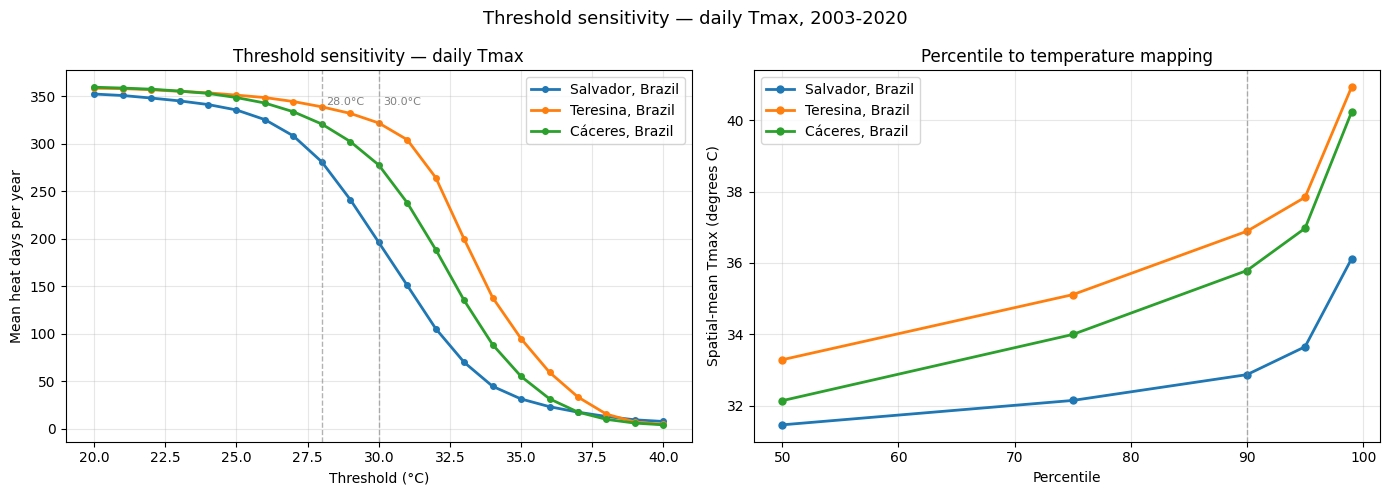

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: heat days per year vs threshold
plot_sensitivity_curves(
    curves, ax=axes[0],
    highlight_thresholds=[ABS_THRESHOLD, ABS_THRESHOLD - 2],
)

# Right: percentile -> spatial-mean temperature for each city
pct_labels = [50, 75, 90, 95, 99]
for c in CITY_KEYS:
    vals = [float(baselines[c].sel(percentile=p).mean()) for p in pct_labels]
    axes[1].plot(pct_labels, vals, marker='o', linewidth=2,
                 markersize=5, label=CITIES[c]['label'])

axes[1].axvline(PERCENTILE, color='grey', linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_xlabel('Percentile')
axes[1].set_ylabel('Spatial-mean Tmax (degrees C)')
axes[1].set_title('Percentile to temperature mapping')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle('Threshold sensitivity — daily Tmax, 2003-2020', fontsize=13)
plt.tight_layout()
plt.show()

## Spatial patterns

Side-by-side choropleth maps for each city showing neighbourhood-level mean
heat days under two threshold framings:

- **Absolute:** days where Tmax >= 30 °C (cross-city comparable)
- **Relative:** days where Tmax exceeds each pixel's own 90th-percentile
  baseline (locally calibrated)

Neighbourhood boundaries are loaded from geobr (2010 census) and cached
locally after the first download.

### Salvador

Loaded 22 neighbourhoods from cache: data/geobr_salvador_neighbourhoods_2010.gpkg


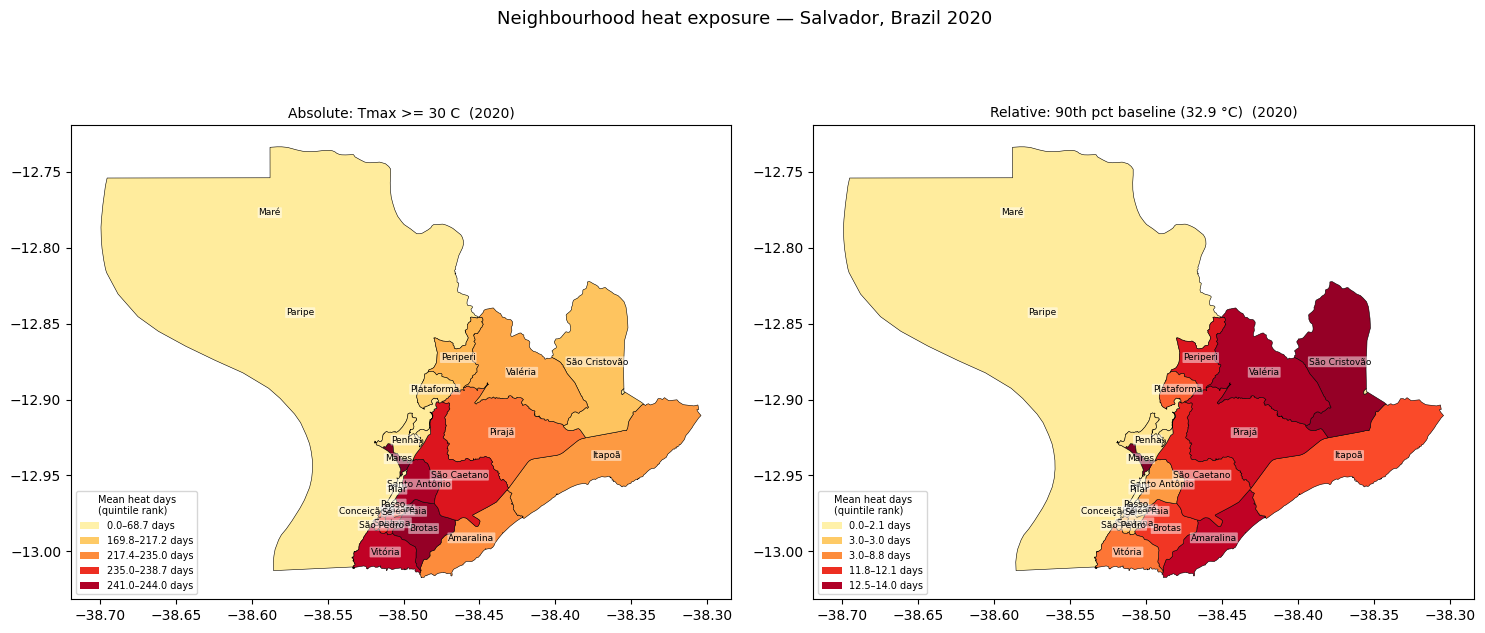

In [5]:
gdf_sal = load_neighbourhood_boundaries('salvador', DATA_DIR)
abs_sal, rel_sal = plot_comparison_maps(
    cities['salvador'], gdf_sal, YEAR, PERCENTILE,
    baselines['salvador'], ABS_THRESHOLD, CITIES['salvador']['label'],
)

### Teresina

Loaded 112 neighbourhoods from cache: data/geobr_teresina_neighbourhoods_2010.gpkg


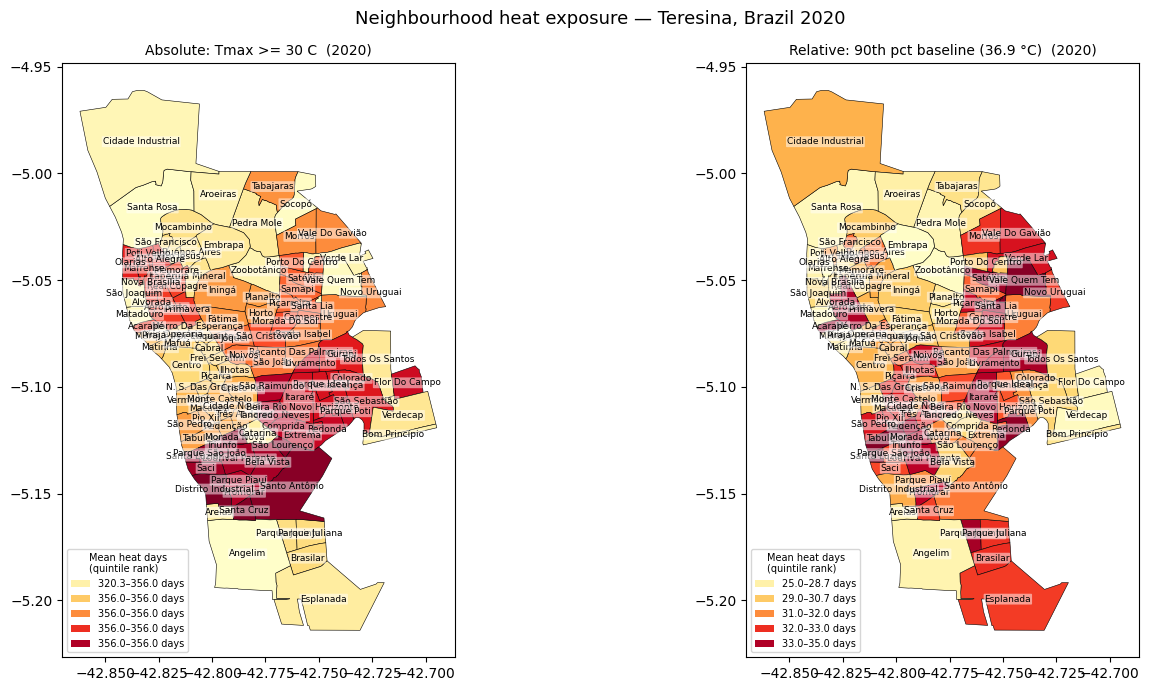

In [6]:
gdf_ter = load_neighbourhood_boundaries('teresina', DATA_DIR)
abs_ter, rel_ter = plot_comparison_maps(
    cities['teresina'], gdf_ter, YEAR, PERCENTILE,
    baselines['teresina'], ABS_THRESHOLD, CITIES['teresina']['label'],
)

### Caceres

Loaded 43 neighbourhoods from cache: data/geobr_caceres_neighbourhoods_2010.gpkg


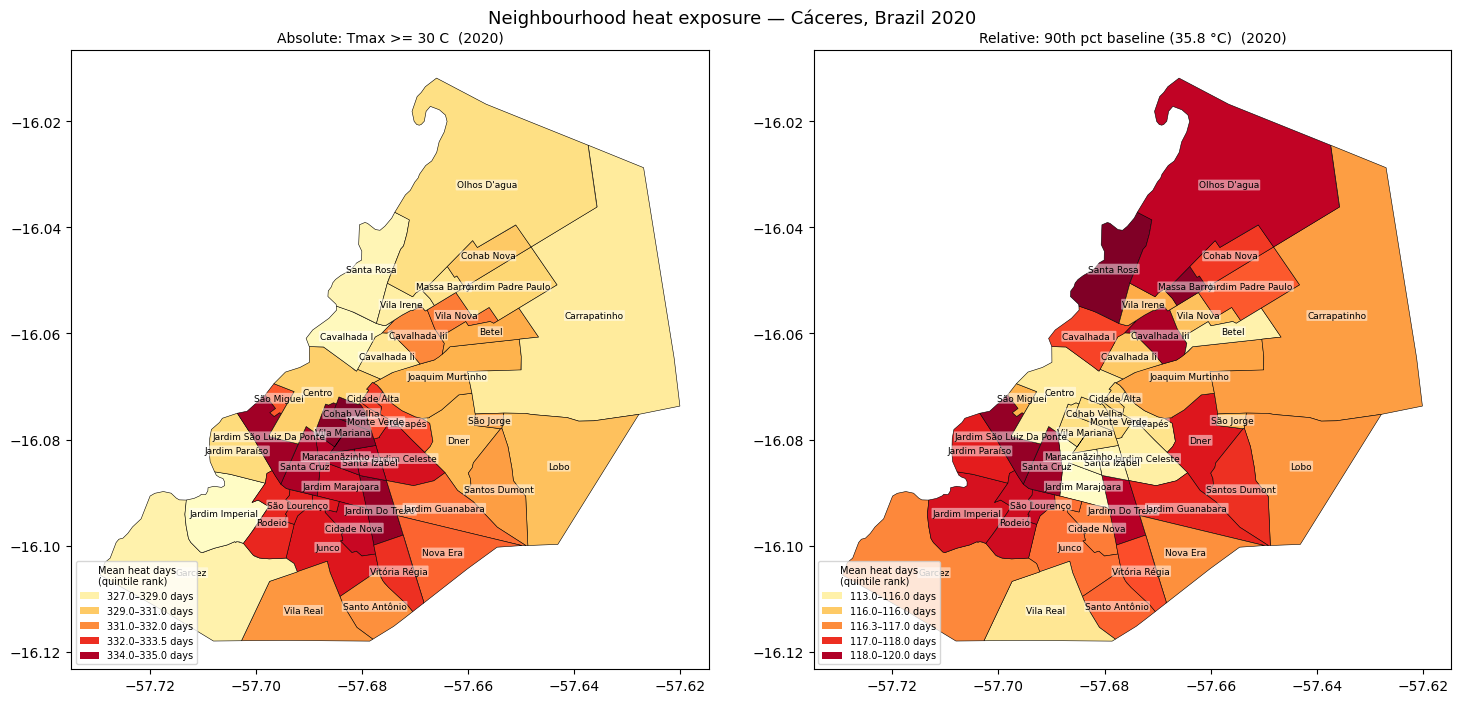

In [7]:
gdf_cac = load_neighbourhood_boundaries('caceres', DATA_DIR)
abs_cac, rel_cac = plot_comparison_maps(
    cities['caceres'], gdf_cac, YEAR, PERCENTILE,
    baselines['caceres'], ABS_THRESHOLD, CITIES['caceres']['label'],
)

In [8]:
## DIAGNOSTICS
## Investigate: (1) why Teresina neighbourhood values cluster
##              (2) which neighbourhoods flip rank abs -> relative

# 1. Pixel-level check for Teresina
abs_map_ter = compute_absolute_heat_days(cities['teresina'], YEAR, ABS_THRESHOLD)
pixel_vals  = abs_map_ter.values.ravel()
pixel_vals  = pixel_vals[~np.isnan(pixel_vals)]
print('TERESINA pixel-level absolute heat days:')
print(f'  pixels        : {len(pixel_vals)}')
print(f'  unique values : {len(np.unique(pixel_vals))}')
print(f'  min/max       : {pixel_vals.min():.0f} / {pixel_vals.max():.0f}')
print(f'  std dev       : {pixel_vals.std():.3f}')

# 2. Neighbourhood-level aggregation for Teresina
_abs_ter = aggregate_to_neighbourhoods(abs_map_ter, gdf_ter)
_rel_map = compute_relative_heat_days(cities['teresina'], YEAR,
                                       baselines['teresina'].sel(percentile=PERCENTILE))
_rel_ter = aggregate_to_neighbourhoods(_rel_map, gdf_ter)

print(f'\nTERESINA neighbourhood absolute heat days ({len(_abs_ter)} neighbourhoods):')
print(f'  unique values : {_abs_ter["mean_heat_days"].nunique()}')
print(f'  min/max       : {_abs_ter["mean_heat_days"].min():.2f} / {_abs_ter["mean_heat_days"].max():.2f}')
print(f'  std dev       : {_abs_ter["mean_heat_days"].std():.3f}')
print(f'  NaN count     : {_abs_ter["mean_heat_days"].isna().sum()}')
print('\nFull list (sorted):')
print(_abs_ter[['name','mean_heat_days']].sort_values('mean_heat_days').to_string())

# 3. Rank flips: Salvador and Caceres
print('\n' + '='*60)
for city_label, a_gdf, r_gdf in [('Salvador', abs_sal, rel_sal), ('Caceres', abs_cac, rel_cac)]:
    merged = (
        a_gdf[['name','mean_heat_days']].rename(columns={'mean_heat_days':'abs_days'})
        .merge(r_gdf[['name','mean_heat_days']].rename(columns={'mean_heat_days':'rel_days'}), on='name')
        .dropna()
    )
    merged['abs_rank']   = merged['abs_days'].rank(ascending=False).astype(int)
    merged['rel_rank']   = merged['rel_days'].rank(ascending=False).astype(int)
    merged['rank_delta'] = merged['rel_rank'] - merged['abs_rank']
    merged = merged.sort_values('rank_delta', ascending=False)
    print(f'\n{city_label} - biggest RISE when switching to relative (cooler baseline, more heat days relatively):')
    print(merged.head(5)[['name','abs_days','abs_rank','rel_days','rel_rank','rank_delta']].to_string(index=False))
    print(f'\n{city_label} - biggest DROP when switching to relative (hotter baseline, fewer relative exceedances):')
    print(merged.tail(5)[['name','abs_days','abs_rank','rel_days','rel_rank','rank_delta']].to_string(index=False))


TERESINA pixel-level absolute heat days:
  pixels        : 5226
  unique values : 13
  min/max       : 0 / 356
  std dev       : 9.957

TERESINA neighbourhood absolute heat days (112 neighbourhoods):
  unique values : 11
  min/max       : 320.30 / 356.00
  std dev       : 4.361
  NaN count     : 0

Full list (sorted):
                      name  mean_heat_days
108                Angelim      320.300000
73              Santa Rosa      326.333333
39                  Socopó      355.000000
54           Vale Quem Tem      355.000000
68             São Joaquim      355.000000
65               Matadouro      355.000000
74       Cidade Industrial      355.200000
42               Verde Lar      355.333333
75                Aroeiras      355.400000
32             Zoobotânico      355.400000
88           Bom Princípio      355.500000
105               Catarina      355.500000
109                 Areias      355.500000
8                Esplanada      355.538462
76                 Embrapa      355

## Neighbourhood prioritisation

Rank each neighbourhood simultaneously on both framings.  Neighbourhoods in
the top-right quadrant (high absolute rank **and** high relative rank) are
robust priorities — they show up as high-burden regardless of which threshold
method is applied.

Spearman rho quantifies agreement between the two rankings; rho near 1 means
the choice of framing barely matters for prioritisation.

### Salvador

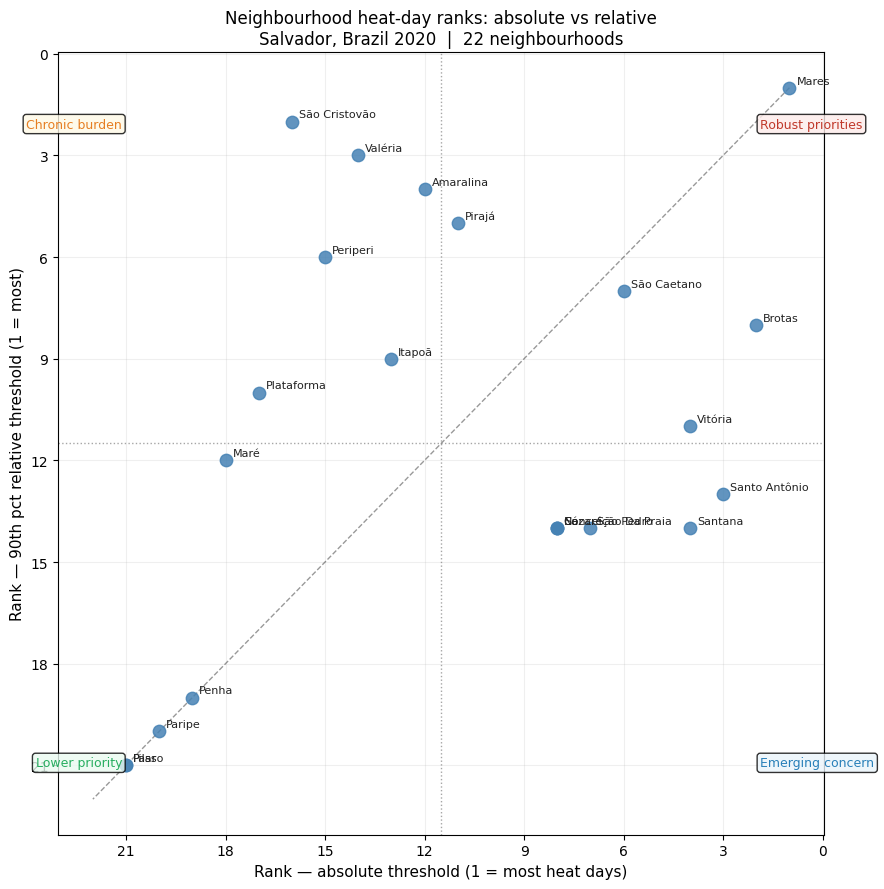

Spearman rho = 0.352  (p = 0.108,  n = 22)


In [9]:
plot_quadrant(abs_sal, rel_sal, YEAR, PERCENTILE, CITIES['salvador']['label'])

### Teresina

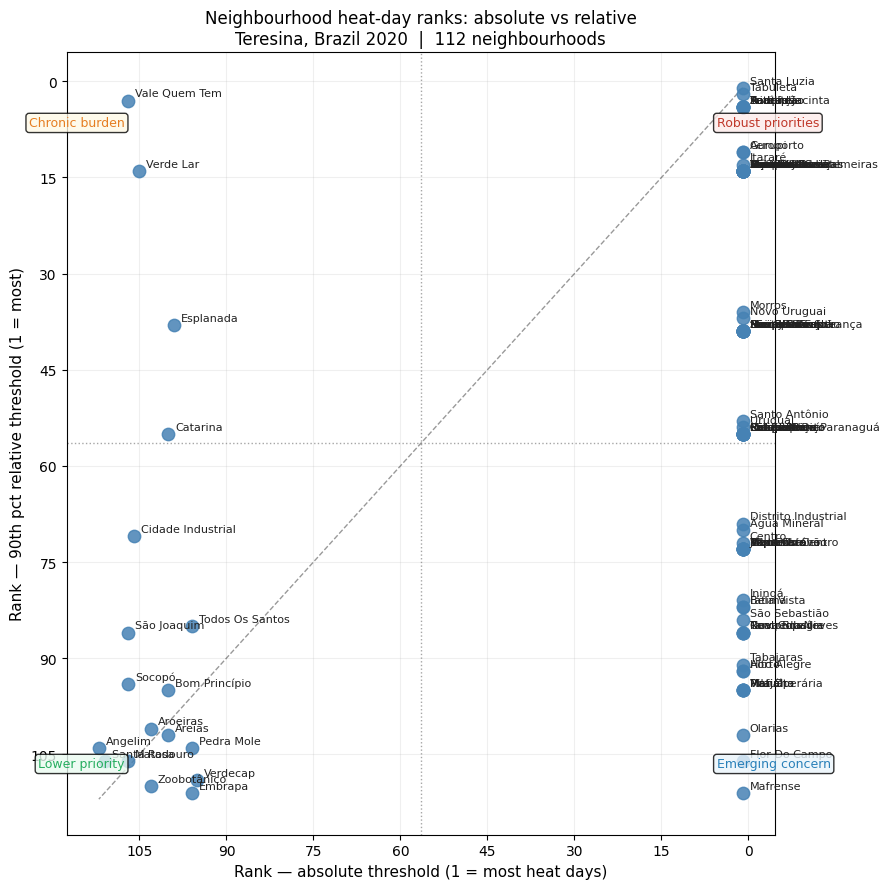

Spearman rho = 0.374  (p = <0.001,  n = 112)


In [10]:
plot_quadrant(abs_ter, rel_ter, YEAR, PERCENTILE, CITIES['teresina']['label'])

### Caceres

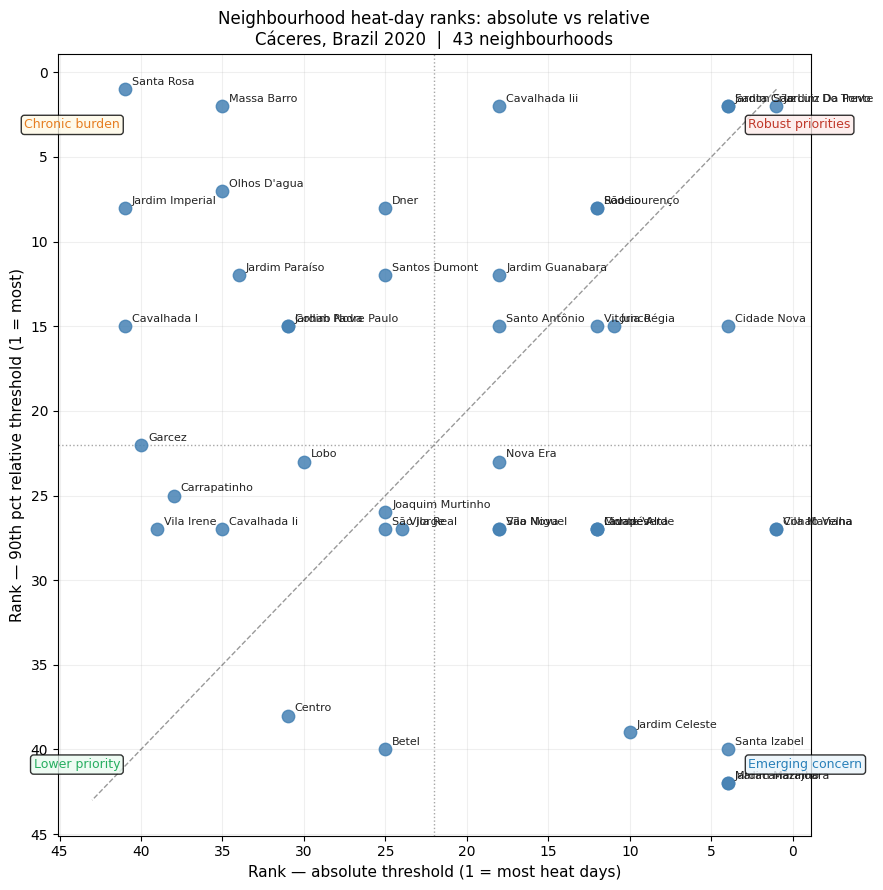

Spearman rho = -0.198  (p = 0.202,  n = 43)


In [11]:
plot_quadrant(abs_cac, rel_cac, YEAR, PERCENTILE, CITIES['caceres']['label'])

## Threshold comparison summary

Average annual heat days per city (2003–2020) under one absolute threshold (Tmax ≥ 30 °C)
and three relative thresholds (P90 / P95 / P99 of the per-pixel baseline).
A second table shows the spatial-mean baseline temperature for each percentile.

In [12]:
REL_PERCENTILES = [90, 95, 99]
ALL_YEARS = list(range(2003, 2021))

count_rows = []
temp_rows  = []

for c in CITY_KEYS:
    da       = cities[c]
    baseline = baselines[c]
    label    = CITIES[c]['label']

    count_row = {'City': label}
    temp_row  = {'City': label}

    # Average annual count over 2003–2020
    abs_annual = [float((da.sel(time=da.time.dt.year == yr) >= ABS_THRESHOLD).sum(dim='time').mean())
                  for yr in ALL_YEARS]
    count_row[f'Abs ≥{ABS_THRESHOLD:.0f} °C'] = float(np.mean(abs_annual))

    for p in REL_PERCENTILES:
        pct_map = baseline.sel(percentile=p)
        rel_annual = [float((da.sel(time=da.time.dt.year == yr) > pct_map).sum(dim='time').mean())
                      for yr in ALL_YEARS]
        count_row[f'P{p}'] = float(np.mean(rel_annual))
        temp_row[f'P{p} (°C)'] = float(pct_map.mean())

    count_rows.append(count_row)
    temp_rows.append(temp_row)

counts = pd.DataFrame(count_rows).set_index('City')
temps  = pd.DataFrame(temp_rows).set_index('City')

table_styles = [
    {'selector': 'caption', 'props': 'font-size:1em; font-weight:bold; padding-bottom:8px;'},
    {'selector': 'th', 'props': 'text-align:center; white-space:nowrap;'},
    {'selector': 'td', 'props': 'text-align:center;'},
]

display(
    counts.style
    .format('{:.1f}')
    .background_gradient(cmap='YlOrRd', axis=None, vmin=0)
    .set_caption('Average annual heat days per city — 2003–2020  (city-wide pixel average)')
    .set_table_styles(table_styles)
)

print()

display(
    temps.style
    .format('{:.1f}')
    .set_caption('Percentile baseline temperatures by city  (spatial mean °C, 2003–2020)')
    .set_table_styles(table_styles)
)

,Abs ≥30 °C,P90,P95,P99
City,,,,
"Salvador, Brazil",63.4,11.4,5.7,1.1
"Teresina, Brazil",322.1,35.0,17.4,3.5
"Cáceres, Brazil",277.6,35.1,17.5,3.5


,P90 (°C),P95 (°C),P99 (°C)
City,,,
"Salvador, Brazil",32.9,33.6,36.1
"Teresina, Brazil",36.9,37.8,40.9
"Cáceres, Brazil",35.8,37.0,40.2


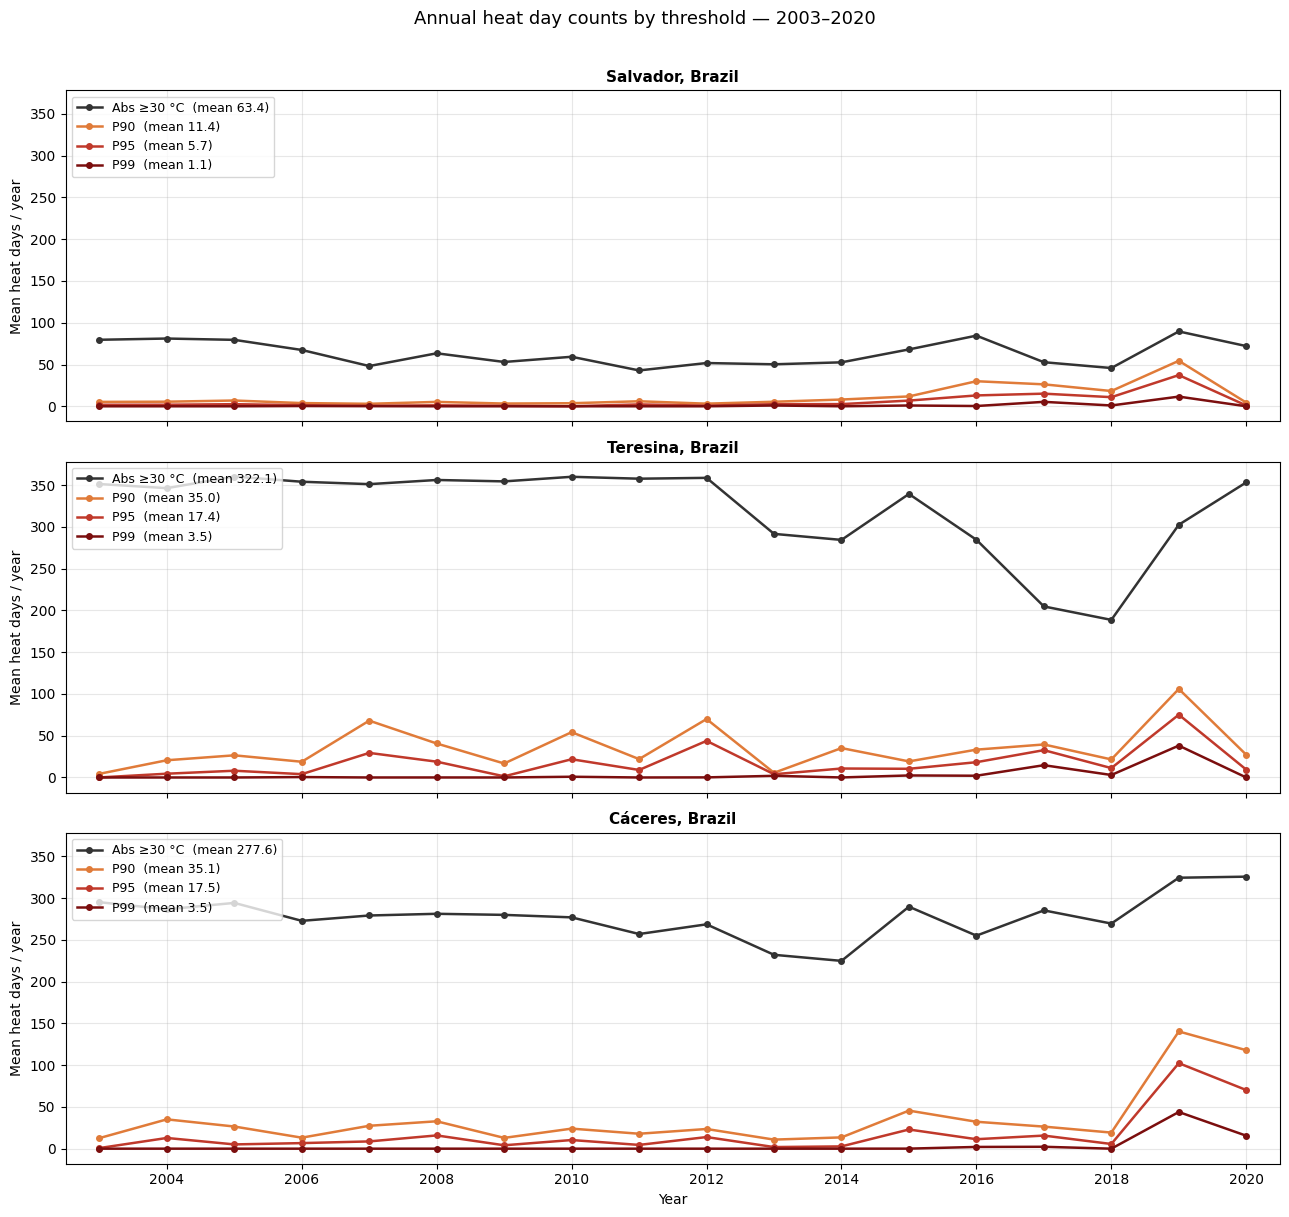

,Abs ≥30 °C,P90,P95,P99
City,,,,
"Salvador, Brazil",63.4,11.4,5.7,1.1
"Teresina, Brazil",322.1,35.0,17.4,3.5
"Cáceres, Brazil",277.6,35.1,17.5,3.5


In [13]:
YEARS = list(range(2003, 2021))
THRESHOLDS = {
    f'Abs ≥{ABS_THRESHOLD:.0f} °C': None,
    'P90': 90,
    'P95': 95,
    'P99': 99,
}
COLOURS = {
    f'Abs ≥{ABS_THRESHOLD:.0f} °C': '#333333',
    'P90': '#e07b39',
    'P95': '#c0392b',
    'P99': '#7b0e0e',
}

fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True, sharey=True)

period_rows = []

for ax, c in zip(axes, CITY_KEYS):
    label    = CITIES[c]['label']
    da       = cities[c]
    baseline = baselines[c]
    period_row = {'City': label}

    for thr_label, pct in THRESHOLDS.items():
        annual_counts = []
        for yr in YEARS:
            da_yr = da.sel(time=da.time.dt.year == yr)
            if pct is None:
                count = float((da_yr >= ABS_THRESHOLD).sum(dim='time').mean())
            else:
                count = float((da_yr > baseline.sel(percentile=pct)).sum(dim='time').mean())
            annual_counts.append(count)

        period_mean = float(np.mean(annual_counts))
        period_row[thr_label] = period_mean

        ax.plot(YEARS, annual_counts, marker='o', markersize=4, linewidth=1.8,
                color=COLOURS[thr_label], label=f'{thr_label}  (mean {period_mean:.1f})')

    period_rows.append(period_row)

    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Mean heat days / year')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(YEARS[0] - 0.5, YEARS[-1] + 0.5)
    ax.xaxis.set_major_locator(plt.MultipleLocator(2))

axes[-1].set_xlabel('Year')
fig.suptitle('Annual heat day counts by threshold — 2003–2020', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Period-average summary table
period_df = pd.DataFrame(period_rows).set_index('City')
display(
    period_df.style
    .format('{:.1f}')
    .background_gradient(cmap='YlOrRd', axis=None, vmin=0)
    .set_caption('2003–2020 period averages — mean heat days per year (city-wide pixel average)')
    .set_table_styles([
        {'selector': 'caption', 'props': 'font-size:1em; font-weight:bold; padding-bottom:8px;'},
        {'selector': 'th', 'props': 'text-align:center; white-space:nowrap;'},
        {'selector': 'td', 'props': 'text-align:center;'},
    ])
)

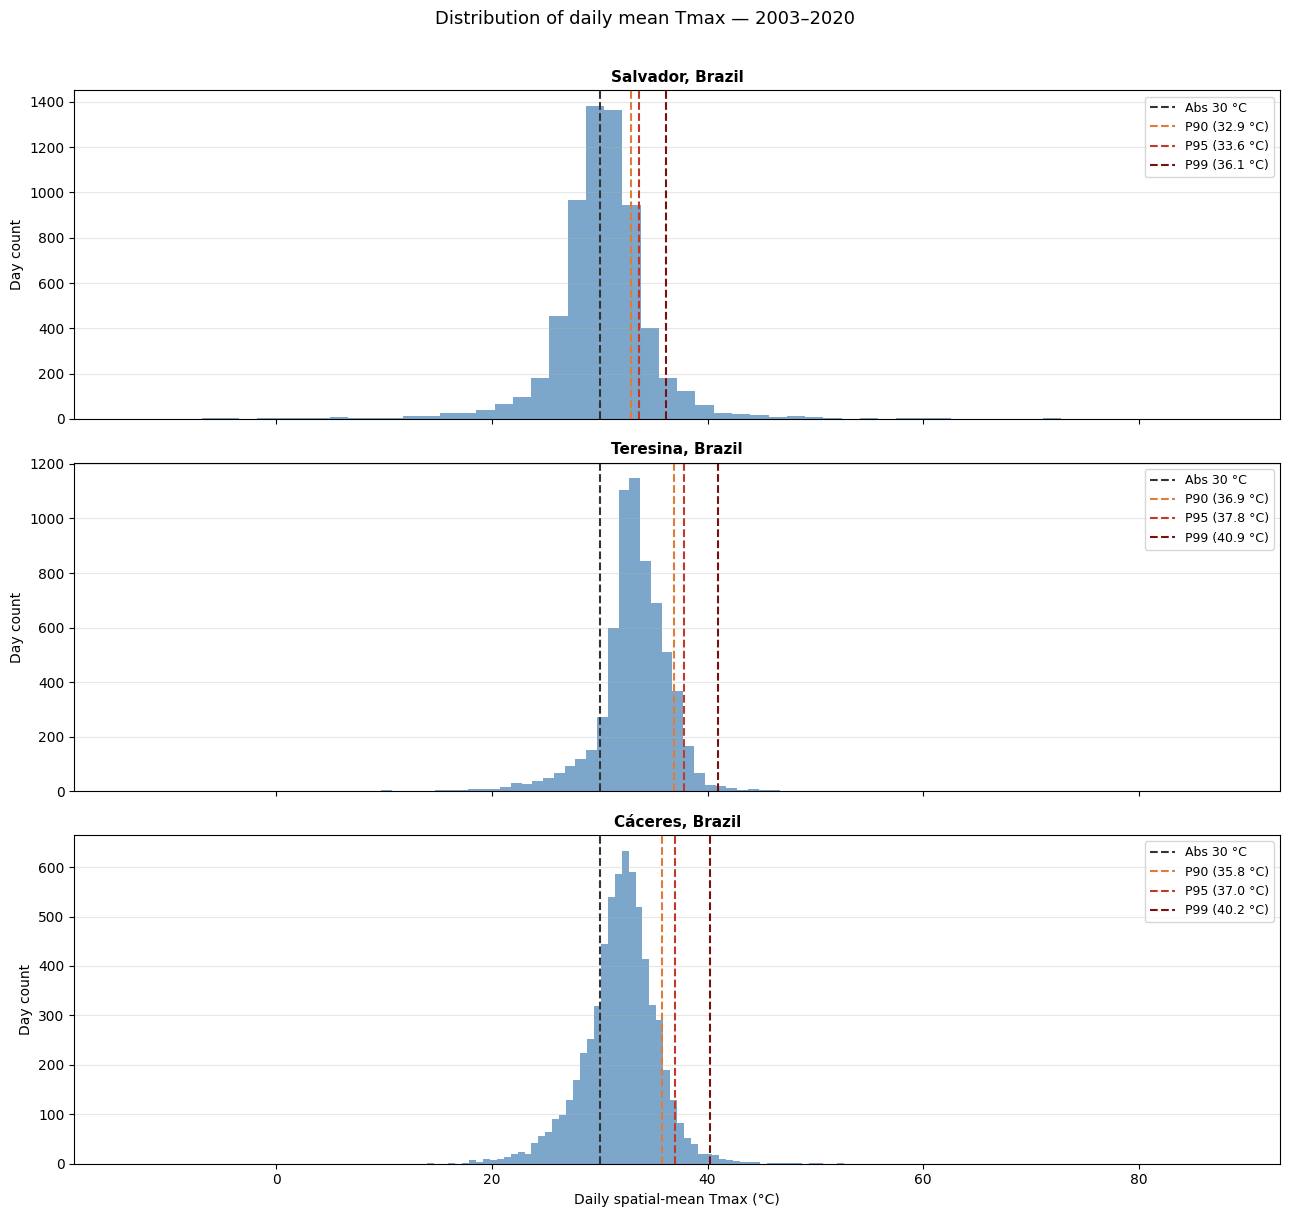

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True, sharey=False)

for ax, c in zip(axes, CITY_KEYS):
    label    = CITIES[c]['label']
    da       = cities[c]
    baseline = baselines[c]

    daily_mean = da.mean(dim=['lat', 'lon']).values

    ax.hist(daily_mean, bins=60, color='steelblue', alpha=0.7, edgecolor='none')

    vlines = {
        f'Abs {ABS_THRESHOLD:.0f} °C': (ABS_THRESHOLD, '#333333'),
        f'P90 ({float(baseline.sel(percentile=90).mean()):.1f} °C)': (float(baseline.sel(percentile=90).mean()), '#e07b39'),
        f'P95 ({float(baseline.sel(percentile=95).mean()):.1f} °C)': (float(baseline.sel(percentile=95).mean()), '#c0392b'),
        f'P99 ({float(baseline.sel(percentile=99).mean()):.1f} °C)': (float(baseline.sel(percentile=99).mean()), '#7b0e0e'),
    }
    for vlabel, (xval, colour) in vlines.items():
        ax.axvline(xval, color=colour, linestyle='--', linewidth=1.5, label=vlabel)

    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Day count')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

axes[-1].set_xlabel('Daily spatial-mean Tmax (°C)')
fig.suptitle('Distribution of daily mean Tmax — 2003–2020', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Summary

Key outputs from this notebook:

1. **Sensitivity curves** — show the steep trade-off between threshold level and
   heat day count, and how the three cities compare at any given threshold.

2. **Percentile-to-temperature mapping** — anchors the abstract percentile labels
   to real temperatures, making the relative threshold interpretable.

3. **Spatial maps** — reveal within-city heterogeneity; absolute and relative
   framings can highlight different neighbourhoods.

4. **Quadrant plots** — identify neighbourhoods that are robustly high-burden
   under both framings, informing prioritisation decisions.

To change the analysis year or threshold, edit the parameters in the Setup
section and re-run from that cell.